# Trader Controls

In its nascent stage, the goal of this trading bot is learning and testing rigging. Fees, swing trade rules, and spreads are key concerns. Its architecture design is mostly conservative, focusing on edge validation in out-of-sample data, and testing operational pipelines end to end. This means monitoring the model to avoid chasing small returns that are eaten by market fees. Test results from `01-trader-metrics.ipynb` adds to this concern, as inital runs yield limited edge in out-of-sample 

This design follows a selective, high-conviction swing strategy plan. This is not a scalper. A trade held for a clean three or five percent move does not care about a 0.2 percent round trip; a trade chasing half a percent is eaten by it, this is our floor.

The minimum-edge floor is enforced to manage high-volume trading where a model of cumulative return appears busier by taking many small trades, while fees quietly eat the account. We propose three guardrails against this: i) a cap limit on number of trades-per-day, ii) minimum-edge floor limit on thinner trades, iii) and after-fee validation protocol. Effectively, this restricts the model from high frequency trades on thinner margins with fees reported. 


### 1. Key Variables

Every tunable parameter below is stored in one `config.py` helper never hard-coded, and the risk-bounding
ones are operator-owned and held outside the model's reach.

The five stages of the pipeline, side by side. Each column is a stage; every name under it is a variable that stage owns. (locked) marks the risk fences: operator-set, reviewed weekly, never tuned by the model. Full definitions live in sections 2 (the screen) and 3 (edge, exit, sizing).

| Selection screen | Edge & exit | Position & frequency | Signal layer | Evaluation harness |
|---|---|---|---|---|
| `quote_volume_24h_usdt` | `round_trip_fee_pct` | `max_trades_per_day` | `macd`, `macd_signal`, `macd_hist` | `oos_window` |
| `atr_pct` | `expected_slippage_pct` | `max_open_positions` | `hist_slope`, `converging` | `train_window` |
| `spread_pct` | `edge_floor_pct` | `position_size_pct` | `cross_up`, `cross_down` | `regime_set` |
| `candle_count` | `take_profit_pct` | `hold_window_days` | `guarded_buy`, `guarded_sell`, `epsilon` | `fee_assumption` |
| `pass` | `stop_loss_pct` | — | `bear_div`, `bull_div` | `experiment_log` |
| — | `net_expected_move` | — | `st_agree`, `st_flip` (Supertrend) | — |


The signal layer's aligned benchmark is the triple-Supertrend (`st_agree`, `st_flip`), shared with chapters 1 and 3; the MACD and vote variables above it are illustrative context, not decision-grade.

### Policing Day Trades

- **Who sets the floor.** The minimum-edge floor is set by the operator or fixed outside the model's reach, never tuned by the model itself. The model is judged on the results the floor produces, so a model that could lower the floor would lower it to book more wins. The floor is reviewed weekly by the operator, not learned.
- **Defence one — trades-per-day cap.** A hard limit on how many trades can exist in a day, set in code. This alone makes the volume trick mechanically impossible: the model cannot churn because it cannot place the orders.
- **Defence two — minimum-edge floor.** A trade is refused unless its expected net move clears the floor. Net means after round-trip fee and after expected slippage, not gross. On Binance crypto the round trip is roughly 0.2 percent, so the floor sits well above that, in the region of one and a half to two percent expected move.
- **Defence three — out-of-sample validation.** Walk-forward only. Tune weights and threshold on a training segment, score once on an untouched test segment, move forward, repeat. Report only the out-of-sample, after-fee, multi-regime aggregate. No in-sample result is ever the verdict.


### Venue Fences

- **Binance crypto.** Round-trip cost roughly 0.15 to 0.2 percent (0.075 percent per side paying fees in BNB, 0.1 percent otherwise). Fee is the binding fence. Keep a BNB balance topped up for the discount.
- **Alpaca equities.** Per-trade cost effectively zero (regulatory pass-throughs on sells only, cents per trade). The binding fence is the pattern-day-trader rule: a sub-25k cash account is capped at three day-trades per rolling five days. Margin interest at 6.25 percent annualized applies to any leveraged overnight hold — trade cash-only to avoid it. 

### Supertrend Integration

A Supertrend band is an ATR-channel trailing stop, so it belongs to this chapter's controls vocabulary: the volatility filter (`compute_atr_pct`), the ATR exit, and position sizing. The live bot trades it long-only behind an EMA-200 gate; its exits (trend flip, flat lower band) are the same family as the edge-fence exit here.

How and where it was integrated:
- **Risk + metrics engine** -> ClaudeTrader (`SuperTrendTradingBot/ClaudeTrader`) is installed editable into the project `.venv`. Its `utils.risk` (ATR stop/take-profit, fixed-fractional and volatility-adjusted sizing, ratcheting trailing stop) and `utils.performance` (Sharpe / Sortino / Calmar / max-drawdown / profit-factor) back the after-fee scoreboard the exit-geometry sweep needs.
- **Baseline** -> `inputs/baseline_supertrend_1h.py` runs the Supertrend exit rules through that risk + performance layer on the out-of-sample year.
- **Import** -> `from utils import risk, performance` (the package squats generic names; alias them). Full record: `tasks/integration-2026-06-23-claudetrader-supertrend.md`.

## Model Design

Chapter Two is the **controls layer**, which includes the four-gate screen, ATR-scaled sizing, 
and the net-edge fee fence, run live on the daily scan. This screening and fencing stage also informs 
the larger multi-resolution (1h, 4h, 5m) full-market dataset used in the next chapter's stage of model 
training and trading execution:

- **Point-in-time screen.** The four-gate screen is now also replayed over history for every
  active USDT pair, so each (coin, hour) training row is kept only if it would have passed as of
  that bar (`screen_membership` in `inputs/build_dataset_1h.py`). Because kline archives carry no
  top-of-book spread, the spread gate is **approximated** by a Corwin-Schultz high-low estimator
  for the historical replay; the live screen here still uses the real spread. The ATR band is
  recalibrated for 1-hour bars.
- **Exit geometry is now tuned, not fixed.** The stop and take-profit are swept on the after-fee
  scoreboard (Priority 1a in `inputs/walkforward.py`, Priority 1b label sweep in
  `inputs/sweep_label_1h.py`; the exit-geometry sweep itself is `inputs/exit_geometry_1h.py`), so the CONFIG values here are a starting point pending that sweep.

### Environment Setup

In [1]:

import sys, subprocess
from pathlib import Path

# Pin the kernel to the same interpreter the rest of the repo uses.
REQUIRED_PY = (3, 11)
if sys.version_info[:2] != REQUIRED_PY:
    raise RuntimeError(
        f"This notebook needs Python {REQUIRED_PY[0]}.{REQUIRED_PY[1]}, "
        f"but the kernel is {sys.version.split()[0]}. Switch the kernel and re-run.")

# Install the exact versions in inputs/requirements.txt (shared with 01-trader-metrics).
REQUIREMENTS = Path("../../03-inputs/requirements.txt")
if not REQUIREMENTS.exists():
    raise FileNotFoundError(f"{REQUIREMENTS} not found - run from the repo root.")
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
    "--break-system-packages", "--disable-pip-version-check",
    "-r", str(REQUIREMENTS)], check=True)

import warnings, numpy as np, pandas as pd
from datetime import datetime, timezone
import ccxt
import plotly, plotly.graph_objects as go, plotly.io as pio
warnings.filterwarnings("ignore")
pio.renderers.default = "plotly_mimetype+notebook_connected"
from IPython.display import HTML, display

def show(fig):
    """Render a plotly figure inline via HTML + CDN.
    .show() with the mimetype renderer can blank out in Positron / VS Code;
    to_html with a CDN plotly.js renders reliably across IDEs (same pattern
    as 01-trader-metrics.ipynb)."""
    display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))

# Resolve outputs to the repo-root outputs/ (absolute, cwd-independent) so the screen CSVs and the
# signal-journal HTML land in the MASTER <repo>/outputs/ and <repo>/outputs/journal/, not a duplicate
# folder beside this notebook. Repo root = parent of the inputs/ dir, found regardless of cwd (as in ch3).
import os
_INPUTS = next((os.path.abspath(c) for c in ("inputs", os.path.join("..", "inputs")) if os.path.isdir(c)), None)
REPO_ROOT = Path(_INPUTS).parent if _INPUTS else Path("..").resolve()
OUTPUTS = REPO_ROOT / "outputs"; OUTPUTS.mkdir(parents=True, exist_ok=True)
print(f"Environment ready  ·  python {sys.version.split()[0]}")
print(f"  ccxt {ccxt.__version__} · pandas {pd.__version__} · "
      f"numpy {np.__version__} · plotly {plotly.__version__}")

Environment ready  ·  python 3.11.13
  ccxt 4.5.59 · pandas 2.3.3 · numpy 2.4.6 · plotly 6.8.0


### Operator Configuration

This realises **§1 Key Variables**. Every tunable lives here in one block, not scattered through the code. The locked entries are the risk-limiting fences that will be operator-set, reviewed weekly, and held outside the model's reach. Secrets stay in your personalized Keychain outside this working repo. When the bot is built and best-fit models are developed, lift this dict into a locked module the strategy file cannot write to.

In [2]:

# -- CONFIG -- outside the model's reach.
CONFIG = dict(
    # Venue fences — Binance crypto round trip (0.075%/side with BNB, 0.1% without)
    round_trip_fee_pct    = 0.15,      # two sides, BNB-discounted; use 0.20 without BNB
    expected_slippage_pct = 0.05,      # modelled slippage per round trip

    # Edge & exit (per-trade economics)
    edge_floor_pct        = 1.5,       # minimum NET expected move to allow a trade
    take_profit_pct       = 10.0,      # target gain; aligned to the Ch3 model label (+10%); must exceed edge_floor_pct
    stop_atr_mult         = 1.5,       # ATR-based stop; the Ch3 label uses a fixed -5% stop, so the stop model (ATR vs fixed) is the open item for 3C exit tuning

    # ATR band — selection filter AND live guardrail
    atr_length            = 14,
    atr_floor_pct         = 2.5,       # below this a coin can't reach TP in the window
    atr_ceiling_pct       = 12.0,      # above this it gaps through stop/TP unpredictably

    # Hard gates (selection screen)
    min_quote_volume_usdt = 30_000_000,# liquidity floor, 24h quote volume USDT
    max_spread_pct        = 0.05,      # spread ceiling, well under the fee
    min_history           = 120,       # candles required to span regimes
    history_limit         = 180,       # candles pulled per coin (90–180)

    # Frequency & position limits
    max_trades_per_day    = 3,         # hard cap — defence one against volume-hiding
    max_open_positions    = 4,         # concurrent positions (3–4 at this account size)
    risk_per_trade_pct    = 1.0,       # % of account risked per trade (constant $ risk)
    max_position_pct      = 30.0,      # cap any single position at this % of account
    min_notional_usdt     = 10.0,      # venue minimum clip; below this a trade isn't worth it

    # Hold window — a walk-forward RANGE, not a fixed number (swing band)
    hold_window_days_min  = 1,
    hold_window_days_max  = 20,        # aligned to the Ch3 model horizon (20 days)

    # Account & scan
    account_usdt          = 750.0,     # proving-rig size (~$500–1000)
    scan_top_n            = 25,        # scan wide (15–25), hold few (3–4)
)

# Public, read-only Binance client (currently not armed for orders).
EXCHANGE = "binance"
exchange = getattr(ccxt, EXCHANGE)()
exchange.set_sandbox_mode(False)   # public market data only

ALLOW_SYNTHETIC = True   # if a live fetch fails (offline / geo-blocked), fall back to
                         # deterministic synthetic data so the notebook still renders.
print(f"Configured {EXCHANGE} | account ${CONFIG['account_usdt']:.0f} | "
      f"edge floor {CONFIG['edge_floor_pct']}% | ATR band "
      f"{CONFIG['atr_floor_pct']}–{CONFIG['atr_ceiling_pct']}% | scan top {CONFIG['scan_top_n']}")

Configured binance | account $750 | edge floor 1.5% | ATR band 2.5–12.0% | scan top 25


### Data Streams

For each coin we pull three pieces of public data through CCXT, the library that talks to the exchange on our behalf:

- The daily price candles, the last 90 to 180 days of open, high, low, close, and volume, dropping the day still in progress so we only ever use finished days.
- The coin's 24-hour trading volume, taken from its ticker, which tells us how heavily it trades.
- The best current buy and sell price, the very top of the order book, which we use only to measure the spread, the small gap between what buyers offer and sellers ask.

We look only at the most heavily traded coins paired with USDT, and only on the single exchange we would actually trade on, rather than casting across every exchange CCXT can reach. If the network is unavailable, each pull quietly falls back to stand-in data so the notebook keeps running instead of crashing.

### Data Sources and Provenance

The four-gate screen and edge-sizing below run on SYNTHETIC OHLCV so the control logic is legible
without a data dependency: the gates, the ATR band, and the Kelly fence are the point here, not the
bars. In production the same logic consumes real data from two places.

Live decisions read the same survivorship-complete archives chapter 1 now scans, with ccxt only as an optional top-up for the forming bar. Backtest and model training read offline,
survivorship-complete frames built in chapter 3 from the official Binance archive at
`data.binance.vision`: monthly per-symbol OHLCV kline zips, one file per interval, exchange-direct and
checksummed. Three resolutions are built today: the original 1h, the 4h (added 2026-06-23 because
1h direction sits at the efficient-market floor), and the 5m scalp probe (added 2026-06-24), with daily planned. Every frame carries the identical
OHLCV schema and the same point-in-time four-gate screen demonstrated here, so this logic transfers
unchanged. The cell below proves the source by pulling one month of 1h, 4h and 5m data straight
from the archive.

In [3]:
# Demo: how the frames are downloaded, and from where. Every frame sources the SAME official Binance
# public archive at data.binance.vision -- monthly per-symbol OHLCV kline zips, one file per interval,
# exchange-direct and checksummed (NOT a live API). ccxt is only a live top-up for the bar still forming.
# This cell pulls one month at 1h, 4h and 5m to prove the source and format; the full pull is the
# commands in the table.
import io, zipfile, urllib.request, pandas as pd
BINANCE_VISION = "https://data.binance.vision/"
def vision_url(symbol, interval, month):
    return f"{BINANCE_VISION}data/spot/monthly/klines/{symbol}/{interval}/{symbol}-{interval}-{month}.zip"

provenance = pd.DataFrame([
    ("1h  (old)", "acquire_vision.py download --interval 1h", "klines_1h/<SYM>/", "dataset_1h_allmarket.parquet"),
    ("1d  (old)", "flow_data.py --interval 1d --all-market",  "klines/<SYM>/",    "daily_flow.csv"),
    ("4h  (new)", "acquire_vision.py download --interval 4h", "klines_4h/<SYM>/", "dataset_4h_allmarket.parquet"),
    ("5m  (new)", "acquire_vision.py download --interval 5m --symbols <scalp set>", "klines_5m/<SYM>/", "dataset_5m_allmarket.parquet"),
], columns=["frame", "download command", "raw klines on disk", "built dataset"])
print("Survivorship-complete: acquire_vision.py crawl enumerates EVERY symbol ever listed (incl.")
print("delisted), so dead coins are not silently dropped the way the exchangeInfo path is.\n")
print(provenance.to_string(index=False))

print("\nLIVE proof of source + format (one month of BTCUSDT, straight from the archive):")
for interval in ("1h", "4h", "5m"):
    u = vision_url("BTCUSDT", interval, "2024-01")
    try:
        raw = urllib.request.urlopen(u, timeout=15).read()
        z = zipfile.ZipFile(io.BytesIO(raw))
        bars = pd.read_csv(io.BytesIO(z.read(z.namelist()[0])), header=None).iloc[:, :6]
        bars.columns = ["open_time", "open", "high", "low", "close", "volume"]
        print(f"  {interval:3s}: {len(bars):5d} bars, {len(raw)/1024:5.0f} KB  <-  {u}")
    except Exception as e:
        print(f"  {interval:3s}: offline ({e}); full archive lives under inputs/binance-data/klines_{interval}/")

Survivorship-complete: acquire_vision.py crawl enumerates EVERY symbol ever listed (incl.
delisted), so dead coins are not silently dropped the way the exchangeInfo path is.

    frame                                               download command raw klines on disk                built dataset
1h  (old)                       acquire_vision.py download --interval 1h   klines_1h/<SYM>/ dataset_1h_allmarket.parquet
1d  (old)                        flow_data.py --interval 1d --all-market      klines/<SYM>/               daily_flow.csv
4h  (new)                       acquire_vision.py download --interval 4h   klines_4h/<SYM>/ dataset_4h_allmarket.parquet
5m  (new) acquire_vision.py download --interval 5m --symbols <scalp set>   klines_5m/<SYM>/ dataset_5m_allmarket.parquet

LIVE proof of source + format (one month of BTCUSDT, straight from the archive):
  1h :   744 bars,    42 KB  <-  https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/1h/BTCUSDT-1h-2024-01.zip
  4h :   186 bars,

In [4]:

def synthetic_ohlcv(symbol, n=None, daily_vol=None, seed=None):
    """Deterministic fake OHLCV for offline/geo-blocked demo. Seeded by symbol."""
    n = n or CONFIG["history_limit"]
    s = abs(hash(symbol)) % (2**32) if seed is None else seed
    rng = np.random.default_rng(s)
    dv = daily_vol if daily_vol is not None else float(rng.uniform(0.01, 0.10))
    rets = rng.normal(0, dv, n)
    close = 100 * np.exp(np.cumsum(rets))
    high  = close * (1 + np.abs(rng.normal(0, dv/2, n)))
    low   = close * (1 - np.abs(rng.normal(0, dv/2, n)))
    openp = np.r_[close[0], close[:-1]]
    vol   = rng.uniform(1e6, 5e6, n)
    idx   = pd.date_range("2025-01-01", periods=n, freq="D")
    return pd.DataFrame({"open":openp,"high":high,"low":low,"close":close,"volume":vol}, index=idx)

def fetch_daily(symbol, limit=None):
    """Daily OHLCV, unclosed bar dropped. Falls back to synthetic if offline."""
    limit = limit or CONFIG["history_limit"]
    try:
        bars = exchange.fetch_ohlcv(symbol, timeframe="1d", limit=limit)
        df = pd.DataFrame(bars[:-1], columns=["timestamp","open","high","low","close","volume"])
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
        return df.set_index("timestamp")
    except Exception as e:
        if ALLOW_SYNTHETIC:
            return synthetic_ohlcv(symbol, n=limit)
        raise

def fetch_quote_volume(symbol):
    """24h quote volume in USDT (the liquidity gate input)."""
    try:
        return float(exchange.fetch_ticker(symbol).get("quoteVolume") or 0.0)
    except Exception:
        if ALLOW_SYNTHETIC:
            return float(np.random.default_rng(abs(hash(symbol))%2**32).uniform(2e6, 2.5e8))
        raise

def fetch_spread_pct(symbol):
    """Top-of-book spread as a percent of mid (the spread gate input)."""
    try:
        ob = exchange.fetch_order_book(symbol, limit=5)
        bid, ask = ob["bids"][0][0], ob["asks"][0][0]
        mid = (bid + ask) / 2
        return (ask - bid) / mid * 100.0
    except Exception:
        if ALLOW_SYNTHETIC:
            return float(np.random.default_rng(abs(hash(symbol))%2**32 + 7).uniform(0.005, 0.12))
        raise

def build_universe(top_n=None):
    """Most-traded /USDT spot pairs by quote volume on the execution venue."""
    top_n = top_n or CONFIG["scan_top_n"]
    try:
        tk = exchange.fetch_tickers()
        usdt = [(s, d.get("quoteVolume") or 0) for s, d in tk.items()
                if s.endswith("/USDT") and ":" not in s]
        uni = [s for s, _ in sorted(usdt, key=lambda x: -x[1])[:top_n]]
        if uni:
            return uni
    except Exception:
        pass
    # offline demo universe: a deliberate spread of regimes for the screen to sort
    print("(offline) using synthetic demo universe")
    return ["BTC/USDT","ETH/USDT","SOL/USDT","BNB/USDT","XRP/USDT","ADA/USDT",
            "AVAX/USDT","LINK/USDT","LTC/USDT","DOGE/USDT","TRX/USDT","DOT/USDT"]

universe = build_universe()
print(f"universe ({len(universe)}):", ", ".join(universe[:12]), "..." if len(universe) > 12 else "")

universe (25): USDC/USDT, BTC/USDT, ETH/USDT, SOL/USDT, USD1/USDT, HYPER/USDT, CELO/USDT, SPCXB/USDT, XRP/USDT, ZEC/USDT, BNB/USDT, RLUSD/USDT ...


### Volatility Filter 

- ATR Band: Average true range across a 14 day period reported as percentage of current price. ATR indicator of typical daily movement.
- Floor: a coin must move enough per day to reach the take-profit inside the hold window. Floor sits above the net edge requirement (i.e. ~2-3% daily ATR).
- Ceiling: above some ATR the coin gaps through stop and take-profit unpredictably and indicators lose meaning. Ceiling sits below where the coin detonates.
- These inform two unrelated operations:
    1. Selection Filter: the gate that admits or rejects a coin from the universe before the model sees it.
    2. Live Guardrail: keeps the model from trading a coin that has drifted out of the tradable band.



In [5]:

def compute_atr_pct(df, length=None):
    """ATR(length) as a percent of price. TR = max(H−L, |H−Cprev|, |L−Cprev|);
    ATR = simple moving average of TR (as written in §2); atr_pct = ATR/price×100."""
    length = length or CONFIG["atr_length"]
    h, l, c = df["high"], df["low"], df["close"]
    pc = c.shift(1)
    tr = pd.concat([(h - l).abs(), (h - pc).abs(), (l - pc).abs()], axis=1).max(axis=1)
    atr = tr.rolling(length).mean()
    return (atr / c) * 100.0

def atr_band_figure(symbol):
    """Live-guardrail view: ATR(14)% over time against the tradable band."""
    df = fetch_daily(symbol)
    atr_pct = compute_atr_pct(df)
    lo, hi = CONFIG["atr_floor_pct"], CONFIG["atr_ceiling_pct"]
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=atr_pct.index, y=atr_pct, name="ATR(14) %",
                             line=dict(color="#0B3D66", width=1.6)))
    fig.add_hrect(y0=lo, y1=hi, fillcolor="#2E8B57", opacity=0.10, line_width=0,
                  annotation_text="tradable band", annotation_position="top left")
    fig.add_hline(y=lo, line=dict(color="#2E8B57", dash="dash"),
                  annotation_text=f"floor {lo}%")
    fig.add_hline(y=hi, line=dict(color="#B22222", dash="dash"),
                  annotation_text=f"ceiling {hi}%")
    fig.update_layout(title=f"{symbol} — daily ATR% vs tradable band (selection + live guardrail)",
                      template="plotly_white", height=360,
                      yaxis_title="ATR(14) as % of price", xaxis_title=None,
                      margin=dict(l=40, r=20, t=50, b=30))
    return fig

show(atr_band_figure(universe[0]))

### 2. Four-Gate Screening

We propose the following screening assessment to evaluate coins individually on a weekly basis.

Inputs: daily OHLCV, last 90–180 candles, plus current order-book top.

- Gate 1 Liquidity - used to reject below floor before computing anything else.
- `quote_volume_24h_usdt` from the ticker. 
 
- Gate 2 ATR Band - reported as percent of price showing average true range per day using:  
  - `TR = max(high−low, |high−prev_close|, |low−prev_close|)`
  - `14-period moving average of TR`
  - `atr_pct = ATR / current_price × 100`
  - `atr_floor_pct ≤ atr_pct ≤ atr_ceiling_pct`. 

- Gate 3 Spread - Rejected if above a tight ceiling that signficantly under the fee floor, derived from order book as:
  - `spread_pct = (ask − bid) / mid × 100` 

- Gate 4 History Range -  Rejects young tokens where Ichimoku cloud clearly lacking:
  - `candle_count < min_history`. 

This informs selection based on `{symbol, quote_volume_24h_usdt, atr_pct, spread_pct, candle_count, pass}`.
Targets include a sample of 15–25 coins allowing positions on 3–4 coins.


In [6]:

def screen_coin(symbol, cfg=CONFIG):
    """Run the four gates on one coin. Liquidity is evaluated first (it is the cheap,
    hard gate); all four numbers are recorded for the table either way."""
    df = fetch_daily(symbol, cfg["history_limit"])
    candle_count = int(len(df))
    quote_vol = fetch_quote_volume(symbol)
    spread = fetch_spread_pct(symbol)
    atr_series = compute_atr_pct(df, cfg["atr_length"])
    atr_pct = float(atr_series.iloc[-1]) if atr_series.notna().any() else float("nan")

    g1 = quote_vol >= cfg["min_quote_volume_usdt"]                       # liquidity (hard)
    g2 = (cfg["atr_floor_pct"] <= atr_pct <= cfg["atr_ceiling_pct"]) if atr_pct == atr_pct else False
    g3 = spread <= cfg["max_spread_pct"]                                 # spread (hard)
    g4 = candle_count >= cfg["min_history"]                              # history (sufficiency)
    gates = {"liquidity": bool(g1), "atr_band": bool(g2), "spread": bool(g3), "history": bool(g4)}
    passed = all(gates.values())
    fail = "" if passed else ",".join(k for k, v in gates.items() if not v)
    return {"symbol": symbol,
            "quote_volume_24h_usdt": round(quote_vol, 0),
            "atr_pct": round(atr_pct, 3),
            "spread_pct": round(spread, 4),
            "candle_count": candle_count,
            "pass": bool(passed), "fail_reason": fail, **gates}

def run_screen(universe, cfg=CONFIG, save=True):
    rows = []
    for s in universe:
        try:
            rows.append(screen_coin(s, cfg))
        except Exception as e:
            print("skip", s, type(e).__name__, str(e)[:60])
    tab = pd.DataFrame(rows).sort_values(["pass", "quote_volume_24h_usdt"],
                                         ascending=[False, False]).reset_index(drop=True)
    if save and len(tab):
        stamp = datetime.now(timezone.utc).strftime("%Y%m%d")
        path = OUTPUTS / f"Candidates_{stamp}.csv"
        tab.to_csv(path, index=False)
        print(f"saved {path}  ({int(tab['pass'].sum())} of {len(tab)} passed)")
    return tab

screen = run_screen(universe)
cols = ["symbol","quote_volume_24h_usdt","atr_pct","spread_pct","candle_count","pass","fail_reason"]
screen[cols]

saved /Volumes/PortableSSD/Github/day-trader/outputs/Candidates_20260701.csv  (7 of 25 passed)


,symbol,quote_volume_24h_usdt,atr_pct,spread_pct,candle_count,pass,fail_reason
0,BTC/USDT,1.303201e+09,3.737,0.0000,179,True,
1,ETH/USDT,3.801523e+08,4.844,0.0006,179,True,
2,SOL/USDT,2.208753e+08,5.839,0.0133,179,True,
3,XRP/USDT,8.084137e+07,4.228,0.0095,179,True,
4,ZEC/USDT,6.505248e+07,9.062,0.0025,179,True,
5,BNB/USDT,6.484535e+07,3.512,0.0018,179,True,
6,DOGE/USDT,5.180600e+07,4.928,0.0138,179,True,
7,USDC/USDT,2.337455e+09,0.059,0.0010,179,False,atr_band
8,USD1/USDT,1.813747e+08,0.051,0.0010,179,False,atr_band
9,HYPER/USDT,1.365444e+08,9.679,0.1291,179,False,spread


The candidate universe is the rows where `pass` is true. The chart below places every scanned coin on the two axes that matter most — liquidity against volatility — with the hard liquidity floor and the ATR band drawn in. Survivors sit inside the green box: liquid enough (above the floor) and lively-but-not-detonating (inside the band).

In [7]:

def screen_scatter(tab, cfg=CONFIG):
    passed = tab[tab["pass"]]; failed = tab[~tab["pass"]]
    fig = go.Figure()
    for d, name, col in [(failed, "rejected", "#B22222"), (passed, "candidate", "#2E8B57")]:
        if len(d):
            fig.add_trace(go.Scatter(
                x=d["atr_pct"], y=d["quote_volume_24h_usdt"], mode="markers+text",
                text=d["symbol"].str.replace("/USDT", ""), textposition="top center",
                textfont=dict(size=9), name=name,
                marker=dict(size=11, color=col, opacity=0.8,
                            line=dict(width=1, color="white"))))
    fig.add_vrect(x0=cfg["atr_floor_pct"], x1=cfg["atr_ceiling_pct"],
                  fillcolor="#2E8B57", opacity=0.07, line_width=0)
    fig.add_vline(x=cfg["atr_floor_pct"], line=dict(color="#2E8B57", dash="dash"))
    fig.add_vline(x=cfg["atr_ceiling_pct"], line=dict(color="#B22222", dash="dash"))
    fig.add_hline(y=cfg["min_quote_volume_usdt"], line=dict(color="#888", dash="dot"),
                  annotation_text="liquidity floor", annotation_position="bottom right")
    fig.update_layout(title="Selection screen — liquidity vs volatility (survivors inside the band, above the floor)",
                      template="plotly_white", height=440, yaxis_type="log",
                      xaxis_title="daily ATR(14) %", yaxis_title="24h quote volume (USDT, log)",
                      margin=dict(l=60, r=20, t=50, b=40))
    return fig

def spread_bars(tab, cfg=CONFIG):
    t = tab.sort_values("spread_pct")
    colors = ["#2E8B57" if v <= cfg["max_spread_pct"] else "#B22222" for v in t["spread_pct"]]
    fig = go.Figure(go.Bar(x=t["symbol"].str.replace("/USDT",""), y=t["spread_pct"],
                           marker_color=colors))
    fig.add_hline(y=cfg["max_spread_pct"], line=dict(color="#888", dash="dash"),
                  annotation_text=f"spread ceiling {cfg['max_spread_pct']}%")
    fig.update_layout(title="Spread gate — top-of-book spread vs ceiling",
                      template="plotly_white", height=320, yaxis_title="spread %",
                      margin=dict(l=50, r=20, t=50, b=40))
    return fig

show(screen_scatter(screen))
show(spread_bars(screen))


### 3. Edge Sizing

**Net edge test (entry gate).** A trade is refused unless:
`net_expected_move = est_move_pct − round_trip_fee_pct − expected_slippage_pct ≥ edge_floor_pct`
Measured on **net**, not gross. This is the fence, not an alarm — it refuses, it does not warn.

**Exit coupling.** Required ordering, enforce in code:
`edge_floor_pct < take_profit_pct` and `atr_floor_pct` large enough that a normal multi-day range
reaches `take_profit_pct` inside `hold_window_days`. `stop_loss_pct` set against the same ATR.

**Volatility-scaled position sizing (industry standard, ATR-based).** Keep dollar risk roughly
constant across coins: size each position so that `stop_loss_pct × position_value ≈ constant risk
budget`. Higher-ATR coin, smaller position; calmer coin, larger. At ~$500–1000 account, floor
position size at the venue's minimum notional, and prefer 3–4 larger positions over many tiny clips
that waste edge on fees and bump minimums.

---

### 4. Hold Period

The earlier "1–3 days" was a gut figure. Resolution: **swing is the band** (days to ~2 weeks),
scalping and day-trading ruled out (fees and PDT rule), position-trading ruled out (underuses the
signal stack). Within the swing band, make `hold_window_days` a **walk-forward parameter** (e.g.
search 1–20 days) and let out-of-sample results pick it. Shorter holds demand higher `atr_pct`;
longer holds tolerate lower. Same dial, two ends.

---

### 5. Autoresearch Lifts

The repo's architecture maps onto this project, but its separation is enforced by **instruction**
("do not modify this file"); a model optimised against the metric needs separation enforced by
**code structure**. Lifts:

- **Narrow editable surface.** Define the one file/module the model may tune; lock everything else
  (evaluation, fee floor, ATR band, guardrails) in files the model cannot write to.

- **Experiment log.** Each walk-forward run writes one line: params tried, OOS after-fee result,
  kept or discarded, why. This is the artefact the operator reviews weekly.

- **Frozen yardstick.** Same OOS windows, fees, regime set across every comparison. Any change to
  the harness is a deliberate, separately-recorded human act, never mid-comparison.

- **program.md pattern.** The human-owned instruction layer (this document / PROJECT-BRIEF.md) is
  iterated by the operator; the model iterates the strategy. Mirrors his program.md vs train.py split.

- **Caution:** trading is adversarial and non-stationary; an OOS metric can rot live in a way his
  fixed-corpus val_bpb never does. The weekly human review is not automatable away.

---

### 6. Design Parameters

#### Stacked Defences

- **Who sets the floor.** Operator-set or fixed outside the model's reach, never tuned by the model. Reviewed weekly.
- **Defence one — trades-per-day cap.** Hard, in code. Churn becomes mechanically impossible.
- **Defence two — minimum-edge floor.** Refuses trades whose net move does not clear the floor.
- **Defence three — out-of-sample validation.** Walk-forward only; report OOS after-fee multi-regime aggregate.

#### Floor Fence

- Refuses the trade; optional alarm band may sit above the fence, but the fence protects the account.
- Measured on estimated move minus fee minus slippage — the honest waterline, above the raw fee.

#### Venue Fences

- **Binance crypto.** Round trip ≈ 0.15–0.20% (0.075%/side with BNB). Fee is the binding fence. Keep BNB topped up.
- **Alpaca equities.** Per-trade ≈ zero (reg pass-throughs, sells only). Binding fence is the PDT rule: sub-25k cash account capped at 3 day-trades / rolling 5 days. Margin interest 6.25%/yr on leveraged overnight holds — trade cash-only. Confirm account is direct self-directed, not partner-routed (else 0%-3% commission band applies).
- Model must know which fence set governs each order.

In [8]:

# -- Net edge fence (entry gate) ---
def net_edge(est_move_pct, cfg=CONFIG):
    """NET expected move after round-trip fee and slippage (not gross)."""
    return est_move_pct - cfg["round_trip_fee_pct"] - cfg["expected_slippage_pct"]

def net_edge_ok(est_move_pct, cfg=CONFIG):
    """The fence: refuse unless net move clears the floor. Refuses, does not warn."""
    return net_edge(est_move_pct, cfg) >= cfg["edge_floor_pct"]

# -- Exit coupling (enforced ordering) ---
def validate_exit_coupling(cfg=CONFIG):
    rt = cfg["round_trip_fee_pct"] + cfg["expected_slippage_pct"]
    days_to_tp = cfg["take_profit_pct"] / cfg["atr_floor_pct"]   # at the ATR floor
    return {
        "edge_floor < take_profit":            cfg["edge_floor_pct"] < cfg["take_profit_pct"],
        "round_trip < edge_floor":             rt < cfg["edge_floor_pct"],
        "take_profit > 2x round_trip (alive)":  cfg["take_profit_pct"] > 2 * rt,
        f"TP reachable at the ATR floor within the window (about {days_to_tp:.1f} days)":
            days_to_tp <= cfg["hold_window_days_max"],
    }

# -- ATR-scaled position sizing (constant dollar risk) ---
def position_plan(atr_pct, cfg=CONFIG, account=None):
    """Size so dollar risk is ~constant across coins: higher ATR -> smaller position.
    stop% = stop_atr_mult × daily ATR%; size = risk_budget / stop%. Capped at
    max_position_pct, floored at the venue minimum notional."""
    account = account or cfg["account_usdt"]
    stop_pct = cfg["stop_atr_mult"] * atr_pct
    risk_budget = account * cfg["risk_per_trade_pct"] / 100.0
    raw = risk_budget / (stop_pct / 100.0) if stop_pct > 0 else 0.0
    capped = min(raw, account * cfg["max_position_pct"] / 100.0)
    final = max(capped, cfg["min_notional_usdt"])
    return {"atr_pct": round(atr_pct, 3), "stop_pct": round(stop_pct, 3),
            "risk_budget_usdt": round(risk_budget, 2), "raw_size_usdt": round(raw, 2),
            "position_usdt": round(final, 2),
            "floored_at_min": bool(final == cfg["min_notional_usdt"] and capped < cfg["min_notional_usdt"])}

print("Net-edge fence (gross est. move -> net -> allowed?):")
for m in (1.0, 1.5, 2.0, 3.5):
    print(f"  est {m:>4}%  ->  net {net_edge(m):>5.2f}%  ->  {'ALLOW' if net_edge_ok(m) else 'refuse'}")

print("\nExit-coupling checks (config must satisfy all):")
for k, v in validate_exit_coupling().items():
    print(f"  [{'ok' if v else 'XX'}] {k}")

Net-edge fence (gross est. move -> net -> allowed?):
  est  1.0%  ->  net  0.80%  ->  refuse
  est  1.5%  ->  net  1.30%  ->  refuse
  est  2.0%  ->  net  1.80%  ->  ALLOW
  est  3.5%  ->  net  3.30%  ->  ALLOW

Exit-coupling checks (config must satisfy all):
  [ok] edge_floor < take_profit
  [ok] round_trip < edge_floor
  [ok] take_profit > 2x round_trip (alive)
  [ok] TP reachable at the ATR floor within the window (about 4.0 days)


Applied to the candidates that cleared the screen, the sizing rule keeps roughly constant dollar risk per trade: a calmer coin earns a larger clip, a livelier one a smaller clip, and nothing is allowed past the per-position cap or below the venue minimum. At this account size the rule pushes toward a few larger positions rather than many tiny clips that waste edge on fees.

In [9]:

cands = screen[screen["pass"]].copy()
if len(cands):
    plans = cands["atr_pct"].apply(lambda a: pd.Series(position_plan(a)))
    sized = pd.concat([cands[["symbol","atr_pct"]].reset_index(drop=True),
                       plans.reset_index(drop=True)[["stop_pct","position_usdt","floored_at_min"]]], axis=1)
    sized = sized.sort_values("position_usdt", ascending=False).reset_index(drop=True)
    display(sized)
    fig = go.Figure(go.Bar(x=sized["symbol"].str.replace("/USDT",""), y=sized["position_usdt"],
                           marker_color="#0B3D66",
                           text=[f"ATR {a:.1f}%" for a in sized["atr_pct"]], textposition="outside"))
    fig.add_hline(y=CONFIG["account_usdt"]*CONFIG["max_position_pct"]/100,
                  line=dict(color="#B22222", dash="dash"),
                  annotation_text=f"position cap ({CONFIG['max_position_pct']}% of acct)")
    fig.add_hline(y=CONFIG["min_notional_usdt"], line=dict(color="#888", dash="dot"),
                  annotation_text="min notional")
    fig.update_layout(title="ATR-scaled position sizing: constant $ risk (higher ATR means a smaller clip)",
                      template="plotly_white", height=360, yaxis_title="position size (USDT)",
                      margin=dict(l=50, r=20, t=50, b=40))
    show(fig)
else:
    print("No candidates cleared the screen on this run — widen the universe or revisit the band.")

,symbol,atr_pct,stop_pct,position_usdt,floored_at_min
0,BNB/USDT,3.512,5.268,142.37,False
1,BTC/USDT,3.737,5.606,133.80,False
2,XRP/USDT,4.228,6.342,118.26,False
3,ETH/USDT,4.844,7.266,103.22,False
4,DOGE/USDT,4.928,7.392,101.46,False
5,SOL/USDT,5.839,8.759,85.63,False
6,ZEC/USDT,9.062,13.593,55.18,False


### Exit Geometry and Entry Trend Context

The exit-geometry view (`03-inputs/exit_geometry_viz.py`), shared with chapter three, rendered here so the
exit points and the trend data around each entry sit beside this chapter's screening and edge-sizing controls. It draws the three
Supertrend trailing lines and EMA-200, shades the trend window before each entry, and annotates the entry
with its Supertrend agreement, EMA-200 side, and RSI; beneath the price it tracks volume, the Supertrend
agreement (0-3) and RSI so the trend building into each entry is legible. Read-only, and it shares the
live bot's exit mechanics.

[single] BTC/USDT 4h: 282 trades  exits: 63 TP / 214 stop / 5 time  mean net +0.07%/trade


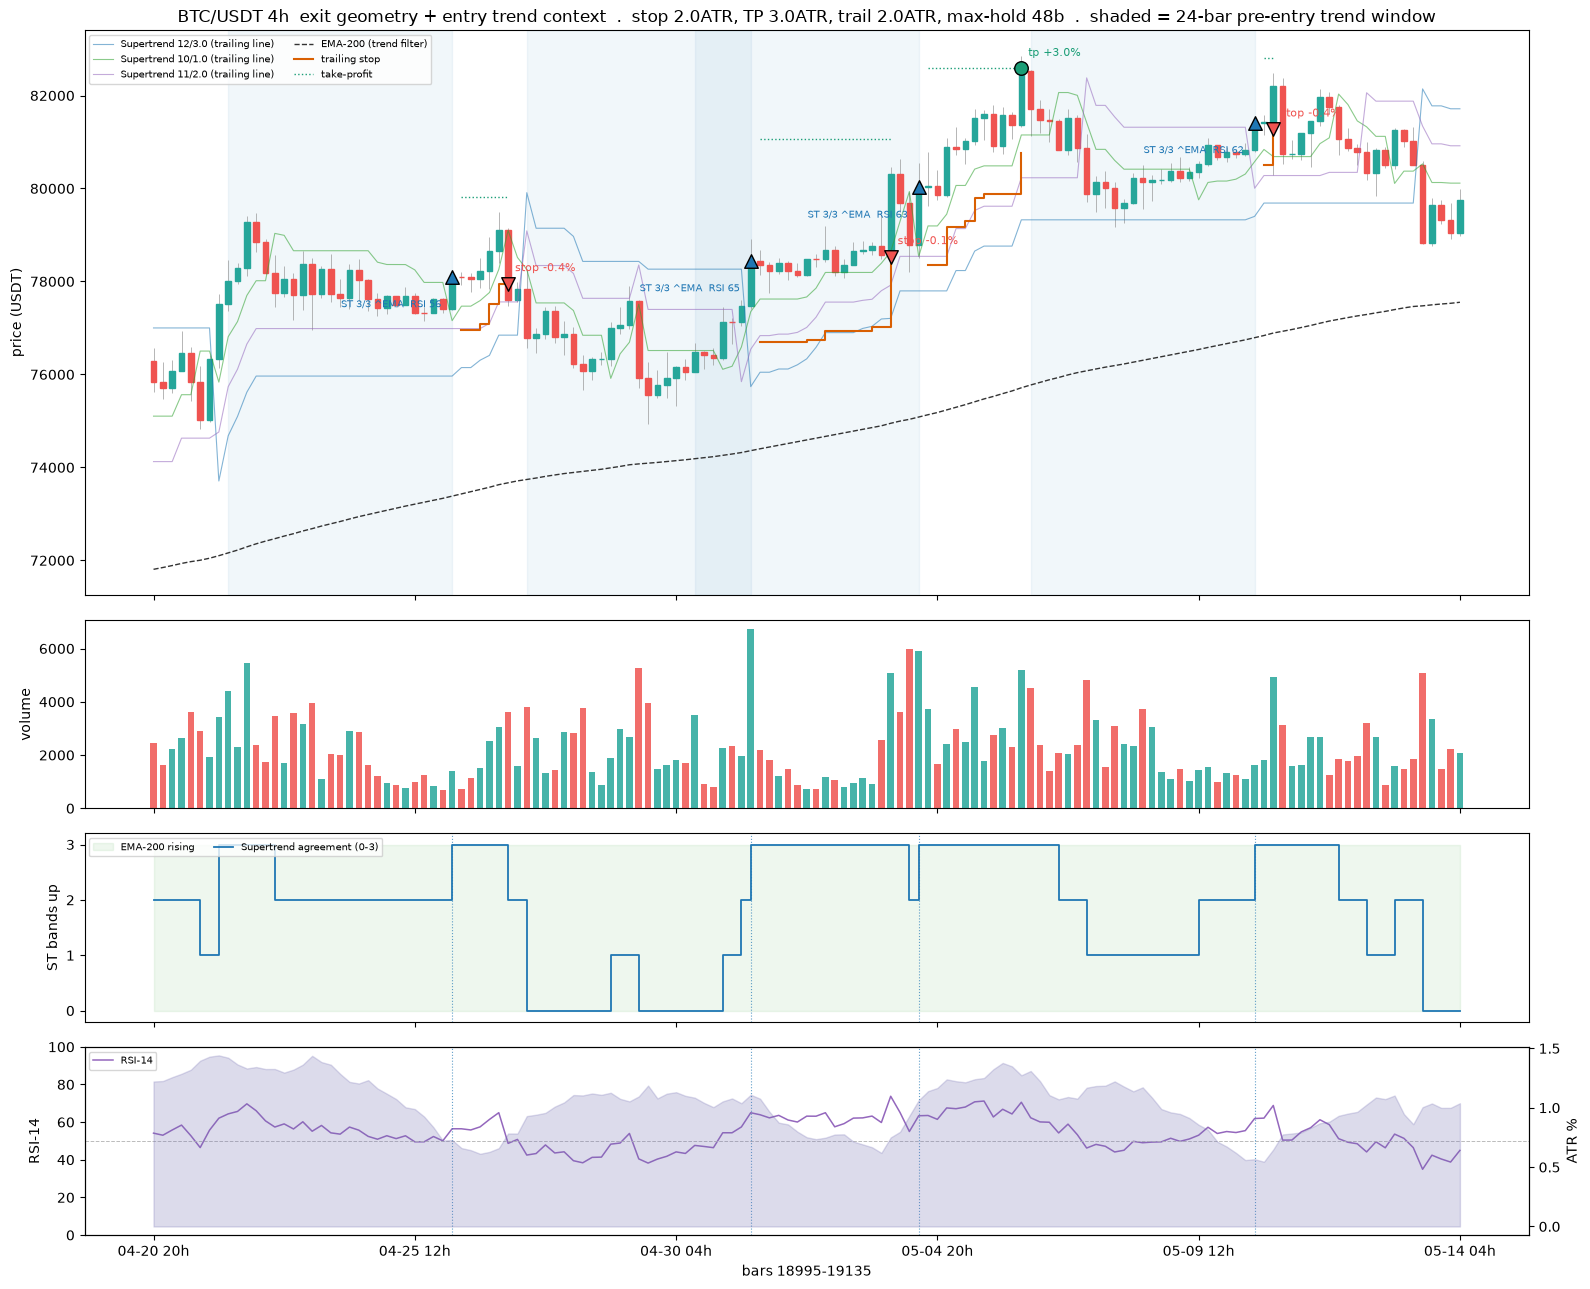

[compare] BTC/USDT 4h: anchored on entry at bar 19113


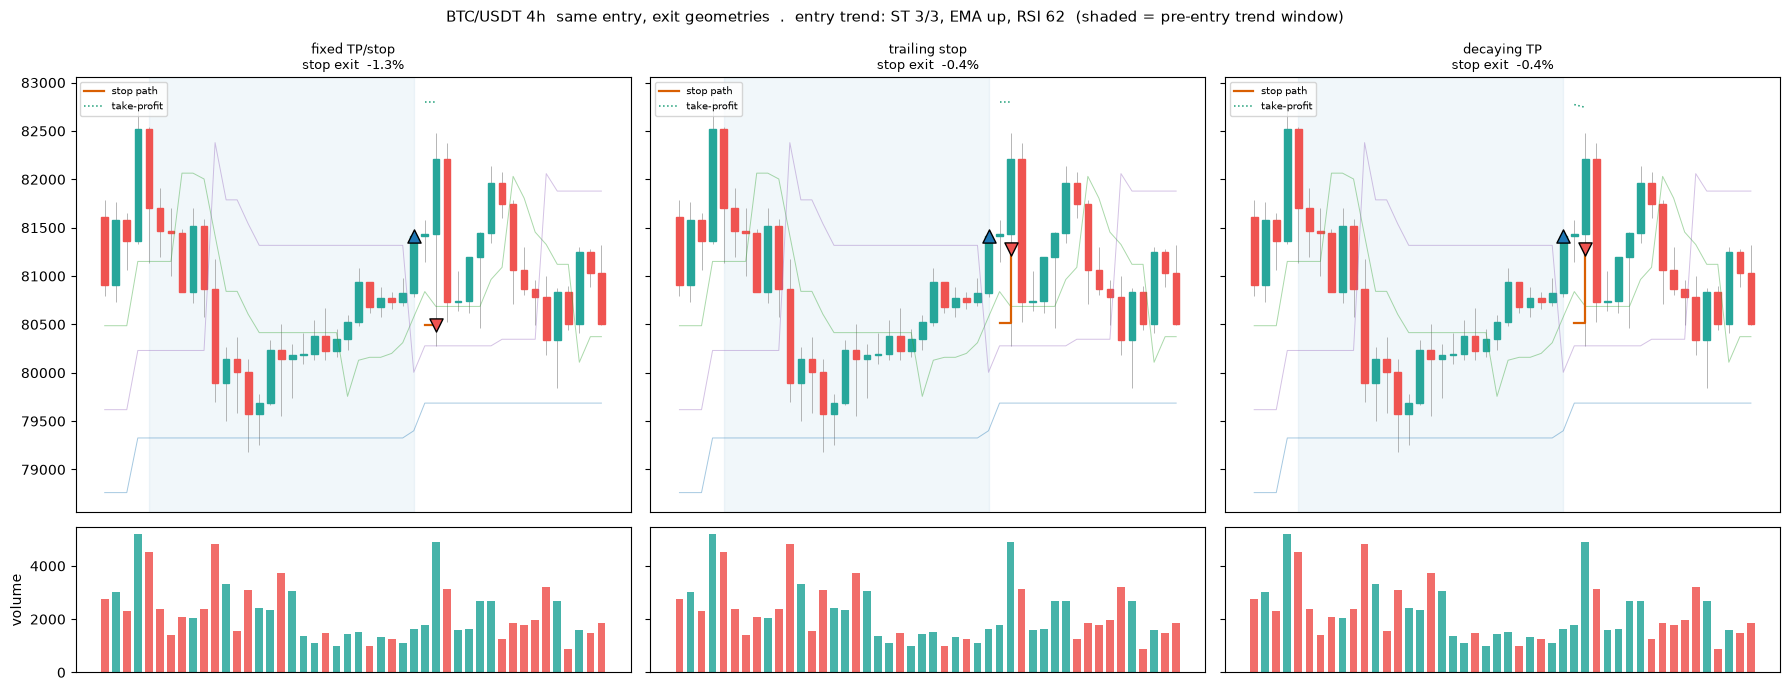

In [10]:
# Exit geometry + entry trend context (single source: 03-inputs/exit_geometry_viz.py)
import os, sys
for _up in (".", "..", "../..", "../../.."):
    _cand = os.path.abspath(os.path.join(_up, "03-inputs"))
    if os.path.isdir(_cand):
        sys.path.insert(0, _cand); break
import exit_geometry_viz as egv
egv.render("BTC/USDT", frame=4, show=True, save=False)   # display inline; chapter three saves the PNGs

### Signal Journal

A learning aid. For each coin this finds every entry and exit the MACD logic produced, draws the candles with the moving averages and a volume histogram beneath, marks every signal, then writes a table beside the chart documenting what the model saw at that moment (trend, RSI, volatility) and whether the fee fence would actually let the trade fire. Each coin's study sheet is saved as a self-contained HTML page under `outputs/journal/`, so a visual library builds up every time you run the screen.

The `net_edge_pct` column uses the take-profit target as a stand-in for the expected move until the predictive model from `day-metrics` supplies a real per-trade estimate; the entries flagged *would fire* are the ones that clear both the fee floor and the ATR band.

In [11]:
from plotly.subplots import make_subplots

def compute_signals(df, cfg=CONFIG):
    """Add MACD, signal, histogram, EMAs, RSI(14), ATR% and crossover flags to a daily frame."""
    c = df["close"]
    df["ema12"] = c.ewm(span=12, adjust=False).mean()
    df["ema26"] = c.ewm(span=26, adjust=False).mean()
    df["macd"]   = df["ema12"] - df["ema26"]
    df["signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["hist"]   = df["macd"] - df["signal"]
    d = c.diff(); up = d.clip(lower=0).rolling(14).mean(); dn = (-d.clip(upper=0)).rolling(14).mean()
    df["rsi"] = 100 - 100 / (1 + up / dn)
    df["atr_pct"] = compute_atr_pct(df, cfg["atr_length"])
    df["cross_up"]   = (df["macd"] > df["signal"]) & (df["macd"].shift(1) <= df["signal"].shift(1))
    df["cross_down"] = (df["macd"] < df["signal"]) & (df["macd"].shift(1) >= df["signal"].shift(1))
    return df

def signal_events(df, cfg=CONFIG):
    """One row per entry/exit, documenting what the model saw and whether the fee fence would let
    an entry fire. est. move uses the take-profit target until the predictive model supplies one."""
    rows = []
    for i in range(1, len(df)):
        buy, sell = bool(df["cross_up"].iloc[i]), bool(df["cross_down"].iloc[i])
        if not (buy or sell):
            continue
        atr = float(df["atr_pct"].iloc[i]); rsi = float(df["rsi"].iloc[i])
        trend = "up" if df["ema12"].iloc[i] > df["ema26"].iloc[i] else "down"
        net = cfg["take_profit_pct"] - cfg["round_trip_fee_pct"] - cfg["expected_slippage_pct"]
        in_band = (cfg["atr_floor_pct"] <= atr <= cfg["atr_ceiling_pct"]) if atr == atr else False
        fires = buy and net >= cfg["edge_floor_pct"] and in_band
        rows.append({
            "date": str(df.index[i].date()),
            "action": "enter / buy" if buy else "exit / sell",
            "price": round(float(df["close"].iloc[i]), 4),
            "trend": trend,
            "rsi": round(rsi, 0) if rsi == rsi else None,
            "atr_pct": round(atr, 2) if atr == atr else None,
            "net_edge_pct": round(net, 2),
            "fence": ("would fire" if fires else
                      "exit" if sell else
                      "blocked: out of band" if not in_band else "blocked: thin edge"),
            "size_usdt": position_plan(atr)["position_usdt"] if fires else None,
            "note": ("MACD crossed above signal -> momentum turning up" if buy
                     else "MACD crossed below signal -> momentum turning down"),
        })
    return pd.DataFrame(rows)

def journal_overview(df, symbol, window=120):
    """Candles + EMAs + buy/sell markers on top, a volume histogram in the middle, MACD underneath."""
    w = df.tail(window)
    vol_col = ["#26a69a" if c >= o else "#ef5350" for o, c in zip(w["open"], w["close"])]
    fig = make_subplots(rows=3, cols=1, shared_xaxes=True, row_heights=[0.62, 0.16, 0.22],
                        vertical_spacing=0.05,
                        subplot_titles=(f"{symbol} - price with model entries (buy) and exits (sell)",
                                        "volume", "MACD (momentum)"))
    fig.add_trace(go.Candlestick(x=w.index, open=w["open"], high=w["high"], low=w["low"], close=w["close"],
                                 name="price", showlegend=False), row=1, col=1)
    fig.add_trace(go.Scatter(x=w.index, y=w["ema12"], line=dict(color="#1f77b4", width=1), name="EMA-12"), row=1, col=1)
    fig.add_trace(go.Scatter(x=w.index, y=w["ema26"], line=dict(color="#9467bd", width=1), name="EMA-26"), row=1, col=1)
    b, s = w[w["cross_up"]], w[w["cross_down"]]
    fig.add_trace(go.Scatter(x=b.index, y=b["low"] * 0.96, mode="markers",
                  marker=dict(symbol="triangle-up", size=12, color="#2E8B57"), name="model buy"), row=1, col=1)
    fig.add_trace(go.Scatter(x=s.index, y=s["high"] * 1.04, mode="markers",
                  marker=dict(symbol="triangle-down", size=12, color="#C0392B"), name="model sell"), row=1, col=1)
    fig.add_trace(go.Bar(x=w.index, y=w["volume"], name="volume", showlegend=False,
                  marker_color=vol_col), row=2, col=1)
    fig.add_trace(go.Bar(x=w.index, y=w["hist"], opacity=0.4, name="histogram",
                  marker_color=["#2E8B57" if h >= 0 else "#C0392B" for h in w["hist"]]), row=3, col=1)
    fig.add_trace(go.Scatter(x=w.index, y=w["macd"], line=dict(color="#0B3D66"), name="MACD"), row=3, col=1)
    fig.add_trace(go.Scatter(x=w.index, y=w["signal"], line=dict(color="#E08A1E"), name="signal"), row=3, col=1)
    fig.update_layout(template="plotly_white", height=680, xaxis_rangeslider_visible=False,
                      margin=dict(l=40, r=20, t=46, b=30), legend=dict(orientation="h", y=1.06))
    return fig

def save_journal(symbol, cfg=CONFIG, outdir=None):
    """Study sheet for one coin: overview chart + an events table documenting the model's actions,
    saved as a self-contained HTML page under outputs/journal/. Returns (path, fig, events)."""
    outdir = Path(outdir or (OUTPUTS / "journal")); outdir.mkdir(parents=True, exist_ok=True)
    df = compute_signals(fetch_daily(symbol, max(cfg["history_limit"], 220)), cfg)
    ev = signal_events(df, cfg)
    fig = journal_overview(df, symbol)
    stamp = datetime.now(timezone.utc).strftime("%Y%m%d")
    path = outdir / f"journal_{symbol.replace('/', '-')}_{stamp}.html"
    last = ev.iloc[-1].to_dict() if len(ev) else {}
    intro = (f"<h2 style='font-family:Arial'>{symbol} - signal journal</h2>"
             f"<p style='font-family:Arial;max-width:820px;color:#333'>Each triangle is a MACD/signal crossover: "
             f"green = the model would consider entering, red = it would exit. The table records what the model saw "
             f"at each point and whether the fee fence would let an entry actually fire. Latest event: "
             f"<b>{last.get('action','-')}</b> on {last.get('date','-')} at {last.get('price','-')} "
             f"({last.get('fence','-')}).</p>")
    style = ("<style>table{border-collapse:collapse;font-family:Arial;font-size:13px}"
             "th,td{border:1px solid #ddd;padding:6px 9px;text-align:left}"
             "th{background:#0B3D66;color:#fff}tr:nth-child(even){background:#f5f7fa}</style>")
    path.write_text("<html><head><meta charset='utf-8'>" + style + "</head><body>" + intro +
                    fig.to_html(include_plotlyjs="cdn", full_html=False) +
                    "<h3 style='font-family:Arial'>What the model saw and did</h3>" +
                    ev.to_html(index=False, border=0) + "</body></html>")
    return path, fig, ev

In [12]:
# Build a journal for the top few coins that cleared tonight's screen (fallback to liquid majors).
try:
    to_study = list(screen[screen["pass"]]["symbol"].head(3))
except Exception:
    to_study = []
if not to_study:
    to_study = ["BTC/USDT", "ETH/USDT", "SOL/USDT"]

journals = []
for sym in to_study:
    try:
        path, fig, ev = save_journal(sym)
        journals.append((sym, path, fig, ev))
        print(f"saved {path}  -  {len(ev)} entries/exits documented")
    except Exception as e:
        print("skip", sym, type(e).__name__, str(e)[:60])
print(f"\n{len(journals)} journal(s) saved under outputs/journal/")

# Show the first journal inline: the chart, then the table of what the model did.
if journals:
    sym, path, fig, ev = journals[0]
    print(f"\n--- {sym} ---")
    show(fig)
    display(ev)

saved /Volumes/PortableSSD/Github/day-trader/outputs/journal/journal_BTC-USDT_20260701.html  -  19 entries/exits documented
saved /Volumes/PortableSSD/Github/day-trader/outputs/journal/journal_ETH-USDT_20260701.html  -  13 entries/exits documented
saved /Volumes/PortableSSD/Github/day-trader/outputs/journal/journal_SOL-USDT_20260701.html  -  15 entries/exits documented

3 journal(s) saved under outputs/journal/

--- BTC/USDT ---


,date,action,price,trend,rsi,atr_pct,net_edge_pct,fence,size_usdt,note
0,2025-11-25,exit / sell,87369.96,down,NaN,NaN,9.8,exit,NaN,MACD crossed below signal -> momentum turning ...
1,2025-11-26,enter / buy,90484.02,up,NaN,NaN,9.8,blocked: out of band,NaN,MACD crossed above signal -> momentum turning up
2,2025-12-01,exit / sell,86286.01,up,NaN,NaN,9.8,exit,NaN,MACD crossed below signal -> momentum turning ...
3,2025-12-02,enter / buy,91277.88,up,NaN,NaN,9.8,blocked: out of band,NaN,MACD crossed above signal -> momentum turning up
4,2025-12-13,exit / sell,90240.01,up,49.0,3.95,9.8,exit,NaN,MACD crossed below signal -> momentum turning ...
5,2025-12-30,enter / buy,88485.49,down,53.0,2.86,9.8,would fire,175.00,MACD crossed above signal -> momentum turning up
6,2026-01-20,exit / sell,88427.66,up,35.0,2.70,9.8,exit,NaN,MACD crossed below signal -> momentum turning ...
7,2026-02-15,enter / buy,68832.58,down,39.0,7.03,9.8,would fire,71.14,MACD crossed above signal -> momentum turning up
8,2026-03-22,exit / sell,67859.00,down,56.0,3.88,9.8,exit,NaN,MACD crossed below signal -> momentum turning ...
9,2026-03-25,enter / buy,71336.53,up,53.0,3.59,9.8,would fire,139.14,MACD crossed above signal -> momentum turning up


### Frozen Harness

The Karpathy lift, adapted: the yardstick is **frozen and operator-owned**, and every walk-forward run appends **one line** — params tried, out-of-sample after-fee result, kept or discarded — to a log the operator reviews weekly. The model never writes to either. This notebook only scaffolds them; the walk-forward loop that fills the log is the next build, and it stays the human's review surface, not something automated away.

In [13]:

# Frozen evaluation harness — versioned, identical across every comparison. (locked)
HARNESS = dict(
    version            = "harness-v1",
    oos_window_days    = 90,
    train_window_days  = 365,
    embargo_days       = 20,                       # straddles the train/test cut
    regime_set         = ["bull", "bear", "sideways"],
    fee_assumption_pct = CONFIG["round_trip_fee_pct"],
    metric             = "oos_after_fee_expectancy",
)

def log_experiment(params: dict, oos_result: dict, kept: bool, why: str,
                   path=OUTPUTS / "experiment_log.csv"):
    """Append one line per walk-forward run. The artefact the operator wakes to."""
    row = {"ts_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
           "harness": HARNESS["version"], "kept": bool(kept), "why": why,
           **{f"p_{k}": v for k, v in params.items()},
           **{f"oos_{k}": v for k, v in oos_result.items()}}
    df = pd.DataFrame([row])
    header = not path.exists()
    df.to_csv(path, mode="a", header=header, index=False)
    return path

# Demonstration entry (replace with real walk-forward output once that loop exists).
p = log_experiment(
    params=dict(edge_floor_pct=CONFIG["edge_floor_pct"], take_profit_pct=CONFIG["take_profit_pct"],
                atr_floor_pct=CONFIG["atr_floor_pct"], threshold=2),
    oos_result=dict(after_fee_expectancy_pct=-0.4, win_rate=0.41, n_trades=37, vs_buy_hold_pct=+1.2),
    kept=False, why="no demonstrated OOS edge after fees (matches standing NO-GO)")
print("logged ->", p)
pd.read_csv(p).tail(3)

logged -> /Volumes/PortableSSD/Github/day-trader/outputs/experiment_log.csv


,ts_utc,harness,kept,why,p_edge_floor_pct,p_take_profit_pct,p_atr_floor_pct,p_threshold,oos_after_fee_expectancy_pct,oos_win_rate,oos_n_trades,oos_vs_buy_hold_pct
0,2026-06-29T23:57:20+00:00,harness-v1,False,no demonstrated OOS edge after fees (matches s...,1.5,10.0,2.5,2,-0.4,0.41,37,1.2
1,2026-07-01T06:03:11+00:00,harness-v1,False,no demonstrated OOS edge after fees (matches s...,1.5,10.0,2.5,2,-0.4,0.41,37,1.2


### Outputs

The dated candidate table and the experiment log are written under `outputs/`, joining the existing run artefacts there. The candidate table is the deliverable the screen produces each week; re-run weekly and the universe refreshes itself.

In [14]:

print("Artefacts written this run:")
for f in sorted(OUTPUTS.glob("Candidates_*.csv")) + [OUTPUTS / "experiment_log.csv"]:
    if f.exists():
        print(f"  {f}  ({f.stat().st_size} bytes)")
print("\nReminder: this notebook screens and sizes only. No orders are placed; "
      "LIVE_TRADING stays 'false' in inputs/config.py and is never read here.")

Artefacts written this run:
  /Volumes/PortableSSD/Github/day-trader/outputs/Candidates_20260629.csv  (1946 bytes)
  /Volumes/PortableSSD/Github/day-trader/outputs/Candidates_20260701.csv  (1959 bytes)
  /Volumes/PortableSSD/Github/day-trader/outputs/experiment_log.csv  (434 bytes)

Reminder: this notebook screens and sizes only. No orders are placed; LIVE_TRADING stays 'false' in inputs/config.py and is never read here.
